In [29]:
import pandas as pd
import os
import torch
import numpy as np
from collections import Counter
import torch.nn as nn
import time
import numpy as np
import torch.optim as optim
import torch.utils.data as data
import matplotlib.pyplot as plt
import glob as glob
from torch.utils.data import TensorDataset, DataLoader  # Add this import

In [25]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [7]:
file = "pose_data_labeled_flipped.csv"
folder = "AugmentedData"

csv_files = glob.glob(os.path.join(folder, '*.csv'))
df_list = [pd.read_csv(f) for f in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)
print(combined_df.shape)
combined_df.to_csv(os.path.join(folder, "combined_data.csv"), index=False)
path = os.path.join(folder, "combined_data.csv")        

(41064, 85)


In [10]:
def manipulate_data(data, window_size):
    action_map = {
        'idle': 0,
        'punch': 1,
        'kick': 2,
    }
    df = pd.read_csv(data)
    df_no_last = df.iloc[:, :-1]  # Exclude the last column
    X, Y = [], []
    for i in range(0, len(df) - window_size - 1, window_size):
        frequency = []
        X.append(df_no_last.iloc[i:(i + window_size), :].values)
        window_labels = df.iloc[i:(i + window_size), -1].values
        frequency = [action_map[label] for label in window_labels]
        if i == 160:
            print(frequency)
        counter = Counter(frequency)
        Y.append(counter.most_common(1)[0][0])

    return np.array(X, dtype = np.float32), np.array(Y, dtype = np.float32)

In [ ]:
window_size = 20
X_aug, Y_aug = manipulate_data(path, window_size)
print(X_aug.shape, Y_aug.shape)#prints (2053, 84, 20) (2053,))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
(2053, 20, 84) (2053,)


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTM(input_size=X_aug.shape[2], hidden_size=128, num_classes=len(np.unique(Y_aug)),num_layers = 2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [31]:
def train_model(model, X, Y, epochs, batch_size):
    model.train()
    
    X_tensor = torch.FloatTensor(X)
    Y_tensor = torch.LongTensor(Y)  # Important: LongTensor for classification
    
    dataset = TensorDataset(X_tensor, Y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        
        avg_loss = epoch_loss / len(dataloader)
        accuracy = 100 * correct / total
        losses.append(avg_loss)
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')
    
    return losses

In [36]:
start_time = time.time()
losses = train_model(model, X_aug, Y_aug, epochs=100, batch_size=16)
end_time = time.time()
print(f"Training time: {end_time - start_time} seconds")

Epoch 0/100, Loss: 0.8144, Accuracy: 67.07%
Epoch 10/100, Loss: 0.3701, Accuracy: 85.73%
Epoch 20/100, Loss: 0.2720, Accuracy: 89.48%
Epoch 30/100, Loss: 0.2335, Accuracy: 91.09%
Epoch 40/100, Loss: 0.2177, Accuracy: 91.48%
Epoch 50/100, Loss: 0.2001, Accuracy: 91.91%
Epoch 60/100, Loss: 0.1795, Accuracy: 92.35%
Epoch 70/100, Loss: 0.1783, Accuracy: 93.23%
Epoch 80/100, Loss: 0.1606, Accuracy: 94.25%
Epoch 90/100, Loss: 0.1283, Accuracy: 95.03%
Training time: 153.8825957775116 seconds


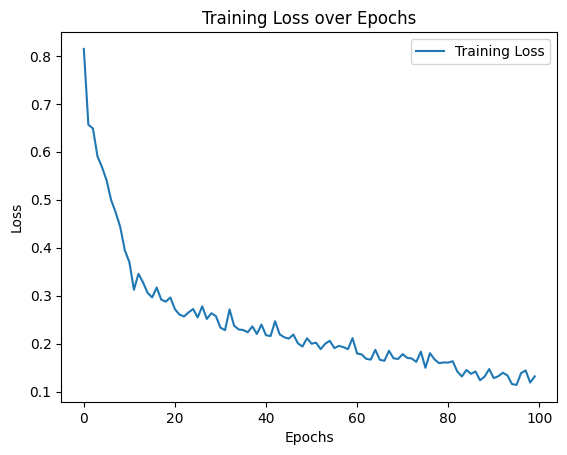

In [37]:
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend(['Training Loss'])
plt.show()